# Predicting Heart Disease Using Machine Learning

In this project, various machine learning and data analysis methods are used as an effort to build a machine learning model that can predict whether a person has heart disease based on their medical attributes. 

The model will predict whether a patient has heart disease or not based on the input clinical parameters.

In creating the ML model, a heart disease patient dataset available on Kaggle was used.
https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

Each column in the data contains clinical parameter information for each patient
- age
- sex : 1 = male, 0 = female
- cp : chest pain type (4 values)
- threstbps : resting blood pressure (mmHg)
- chol : serum cholestoral (mg/dl)
- fbs : fasting blood sugar > 120 mg/dl (1=True, 0=False)
- restecg : resting electrocardiographic - results (values 0,1,2)
- thalach: maximum heart rate achieved
- exang: exercise induced angina (1=Yes, 0=No)
- oldpeak: ST depression induced by exercise relative to rest
- slope: the slope of the peak exercise ST segment
- ca: number of major vessels (0-3) colored by flourosopy
- thal: 0 = normal; 1 = fixed defect; 2 = reversable defect
- target:  1 = Heart disease, 0 = non-heart disease

## Preparation

In [4]:
#prepare the tools
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

%matplotlib inline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import StandardScaler


In [5]:
#load the data
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Exploratory Data Analysis

In [6]:
#EDA
df["target"].value_counts()


target
1    526
0    499
Name: count, dtype: int64

<Axes: xlabel='target'>

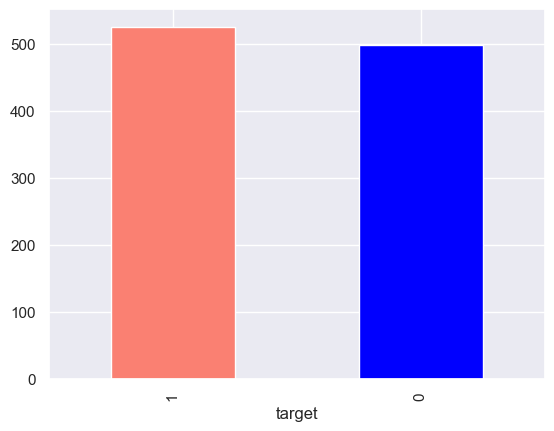

In [7]:
df["target"].value_counts().plot(kind="bar", color=["salmon", "blue"])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [9]:
#find missing values
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [10]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [11]:
#heart diseaase fequency according to sex
#df.sex.value_counts()
df["sex"].value_counts()


sex
1    713
0    312
Name: count, dtype: int64

In [12]:
#compare target column with sex column
pd.crosstab(df.target, df.sex)

sex,0,1
target,,
0,86,413
1,226,300


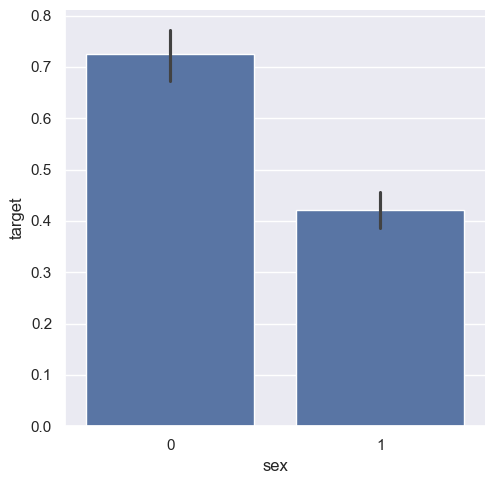

In [13]:
sns.catplot(data=df, kind="bar", x="sex", y="target")

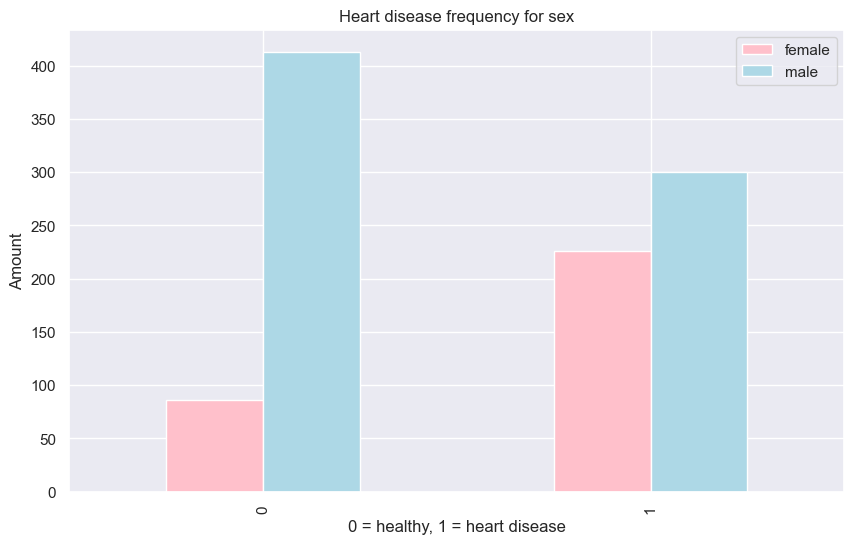

In [14]:
##creating a plot of crosstab
pd.crosstab(df.target, df.sex).plot(kind="bar", figsize=(10,6), color=["pink", "lightblue"])

plt.title("Heart disease frequency for sex")
plt.xlabel("0 = healthy, 1 = heart disease")
plt.ylabel("Amount")
plt.legend(["female", "male"])

<Axes: ylabel='Frequency'>

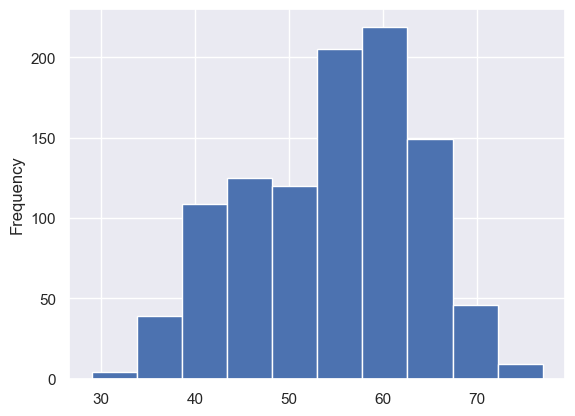

In [15]:
#checking the distribution of the age column with a histogram
df.age.plot.hist()

Heart disease frequency per chest pain type
cp: chest pain type

0 -> value 1: typical angina
1 -> value 2: atypical angina
2 -> value 3: non-angina pain
3 -> value 4: asymptomatic

In [16]:
pd.crosstab(df.cp, df.target)

target,0,1
cp,,
0,375,122
1,33,134
2,65,219
3,26,51


(array([0, 1, 2, 3]),
 [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

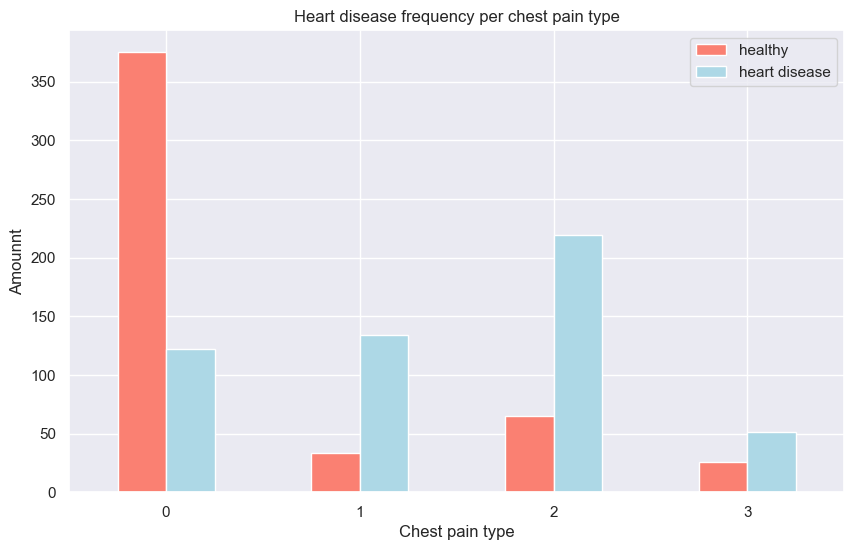

In [17]:
#make the crosstab more visual with a plot
pd.crosstab(df.cp, df.target).plot(kind="bar", figsize=(10,6), color=["salmon", "lightblue"])

plt.title("Heart disease frequency per chest pain type")
plt.xlabel("Chest pain type")
plt.ylabel("Amounnt")
plt.legend(["healthy", "heart disease"])
plt.xticks(rotation=0)

In [18]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [19]:
#Make correlation matrix
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.103240,-0.071966,0.271121,0.219823,0.121243,-0.132696,-0.390227,0.088163,0.208137,-0.169105,0.271551,0.072297,-0.229324
sex,-0.103240,1.000000,-0.041119,-0.078974,-0.198258,0.027200,-0.055117,-0.049365,0.139157,0.084687,-0.026666,0.111729,0.198424,-0.279501
cp,-0.071966,-0.041119,1.000000,0.038177,-0.081641,0.079294,0.043581,0.306839,-0.401513,-0.174733,0.131633,-0.176206,-0.163341,0.434854
trestbps,0.271121,-0.078974,0.038177,1.000000,0.127977,0.181767,-0.123794,-0.039264,0.061197,0.187434,-0.120445,0.104554,0.059276,-0.138772
chol,0.219823,-0.198258,-0.081641,0.127977,1.000000,0.026917,-0.147410,-0.021772,0.067382,0.064880,-0.014248,0.074259,0.100244,-0.099966
fbs,0.121243,0.027200,0.079294,0.181767,0.026917,1.000000,-0.104051,-0.008866,0.049261,0.010859,-0.061902,0.137156,-0.042177,-0.041164
restecg,-0.132696,-0.055117,0.043581,-0.123794,-0.147410,-0.104051,1.000000,0.048411,-0.065606,-0.050114,0.086086,-0.078072,-0.020504,0.134468
thalach,-0.390227,-0.049365,0.306839,-0.039264,-0.021772,-0.008866,0.048411,1.000000,-0.380281,-0.349796,0.395308,-0.207888,-0.098068,0.422895
exang,0.088163,0.139157,-0.401513,0.061197,0.067382,0.049261,-0.065606,-0.380281,1.000000,0.310844,-0.267335,0.107849,0.197201,-0.438029
oldpeak,0.208137,0.084687,-0.174733,0.187434,0.064880,0.010859,-0.050114,-0.349796,0.310844,1.000000,-0.575189,0.221816,0.202672,-0.438441


<Axes: >

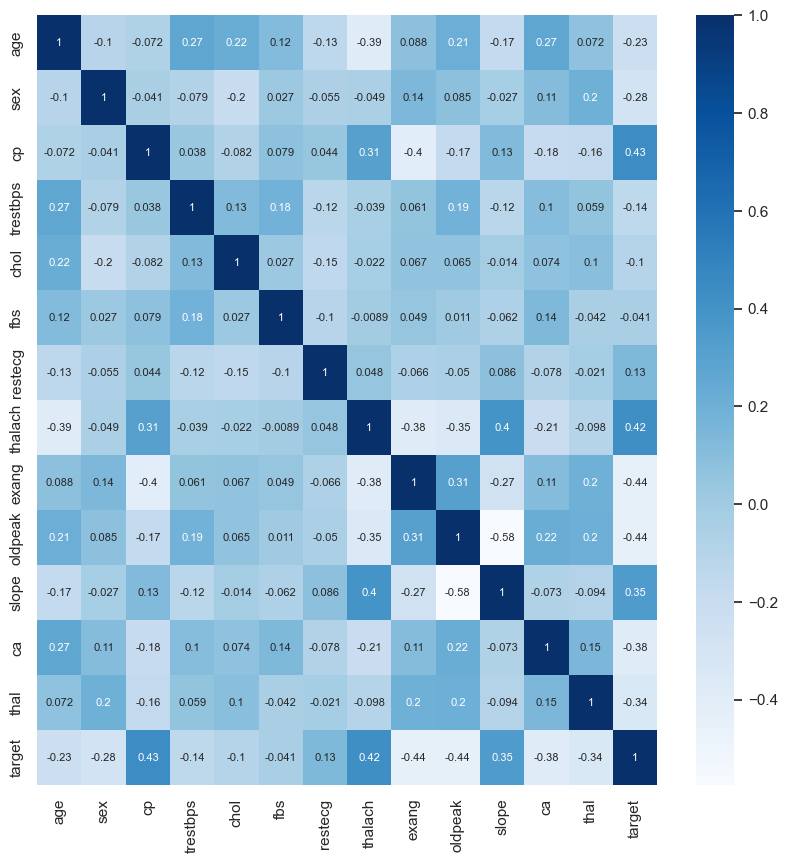

In [20]:
#Make heatmap of correlation matrix
plt.figure(figsize=(10,10))
corr = df.corr()
sns.heatmap(corr, annot=True, annot_kws={"size":8}, cmap='Blues')

## Modelling
Define the X axis an Y axis

In [21]:
df.groupby('target').mean()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
target,,,,,,,,,,,,,
0,56.569138,0.827655,0.482966,134.106212,251.292585,0.164329,0.456914,139.130261,0.549098,1.600200,1.166333,1.158317,2.539078
1,52.408745,0.570342,1.378327,129.245247,240.979087,0.134981,0.598859,158.585551,0.134981,0.569962,1.593156,0.370722,2.119772


In [22]:
#split the data into x and y
x = df.drop("target", axis=1)
y = df['target']

In [23]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2


In [24]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64

In [25]:
#split data into train and test sets
np.random.seed(42)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [26]:
x_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
835,49,1,2,118,149,0,0,126,0,0.8,2,3,2
137,64,0,0,180,325,0,1,154,1,0.0,2,0,2
534,54,0,2,108,267,0,0,167,0,0.0,2,0,2
495,59,1,0,135,234,0,1,161,0,0.5,1,0,3
244,51,1,2,125,245,1,0,166,0,2.4,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,41,1,2,130,214,0,0,168,0,2.0,1,0,2
71,61,1,0,140,207,0,0,138,1,1.9,2,1,3
106,51,1,0,140,299,0,1,173,1,1.6,2,0,3
270,43,1,0,110,211,0,1,161,0,0.0,2,0,3


In [27]:
y_train, len(y_train)

(835    0
 137    1
 534    1
 495    1
 244    1
       ..
 700    1
 71     0
 106    0
 270    1
 860    0
 Name: target, Length: 820, dtype: int64,
 820)

In [28]:
print(x.shape, x_train.shape, x_test.shape)

(1025, 13) (820, 13) (205, 13)


### Build machine learning models

Try 4 different machine learning models
1. K-Nearest Neighbours Classifier
2. Logistic Regression
3. Random Forest Classifier
4. SVC

In [29]:
#put models in a dictionary
models = {"Logistic Regression": LogisticRegression(),
          "KNN": KNeighborsClassifier(),
          "Random Forest": RandomForestClassifier(),
          "SVC": SVC()}

#create a function to fit and score models
def fit_and_score(models, x_train, x_test, y_train, y_test):
    """
    Fits and evaluate given machine learning models.
    models : a dict of different scikit_learn machine learning models
    x_train : train data (no labels)
    x_test : test data (no labels)
    y_train : training labels
    y-test : testing labels
    """
    #set random seed
    np.random.seed(42)

    #Make a dictionary to keep model scores
    model_scores = {}
    #Loop through models
    for name, model in models.items() :
        #fit model to the data
        model.fit(x_train, y_train)
        #evaluate the model and append its score to model_scores
        model_scores[name] = model.score(x_test, y_test)
    return model_scores

In [30]:
#fit and score models
model_scores = fit_and_score(models = models,
                             x_train = x_train,
                             x_test = x_test,
                             y_train = y_train,
                             y_test = y_test)

model_scores


C:\Users\Jihan\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regression': 0.7853658536585366,
 'KNN': 0.7317073170731707,
 'Random Forest': 0.9853658536585366,
 'SVC': 0.6829268292682927}

### Model comparison
Comparing ML models by accuracy. Since the data quite balance between Heart disease and non-heart disease subject, we can evaluate the overall correctness of the models. 

Accuracy = (TP + TN)/ (TP + TN + FP + FN)

<Axes: >

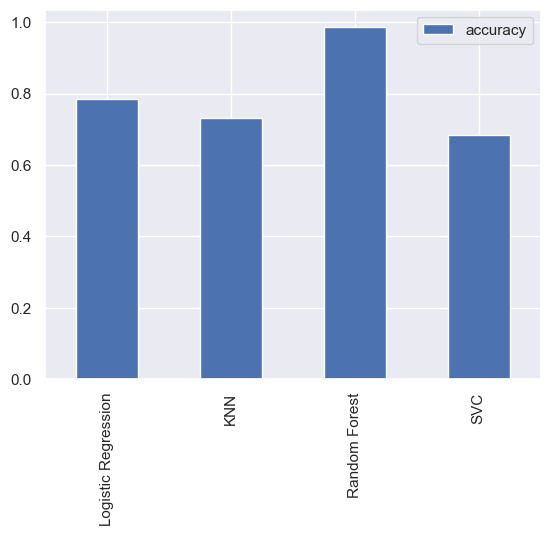

In [31]:
model_compare = pd.DataFrame(model_scores, index = ["accuracy"])
model_compare.T.plot.bar()

## Hyperparameter tuning
Hyperparameter tuning (or hyperparameter optimization) is the process of finding the hyperparameter configuration that yields the best performance. 

In KNN, the primary hyperparameters are the number of neihgbors (K), the distance matrix, and the weighting scheme.
- The k parameter determines how many nearest neighbors to consider when making a prediction. A smaller k can lead to overfitting, while a larger k can result in underfitting. Cross-validation is often used to find the optimal k.
- The distance metric defines how the distance between data points is calculated. Common metrics include Euclidean, Manhattan, and Minkowski distances.
- The weighting scheme determines how much influence each neighbor has on the prediction. Options include uniform weights (all neighbors contribute equally) and distance-based weights (closer neighbors have more influence).

In [32]:
# Let's tune KNN

train_scores = []
test_scores = []

# crate a list of different values for n_neighbors
neighbors = range(1,21)

# setup = KNN instance for tuning
knn = KNeighborsClassifier()

#loop through differnt n_neighbors
for i in neighbors:
    knn.set_params(n_neighbors=i)

    #fit teh algorithm
    knn.fit(x_train, y_train)

    #update the training scores list
    train_scores.append(knn.score(x_train, y_train))

    #update the test scores list
    test_scores.append(knn.score(x_test, y_test))

test_scores

[0.9853658536585366,
 0.9560975609756097,
 0.9024390243902439,
 0.8097560975609757,
 0.7317073170731707,
 0.6878048780487804,
 0.6780487804878049,
 0.6682926829268293,
 0.7170731707317073,
 0.7170731707317073,
 0.6878048780487804,
 0.6780487804878049,
 0.6780487804878049,
 0.7170731707317073,
 0.7073170731707317,
 0.6926829268292682,
 0.6780487804878049,
 0.7073170731707317,
 0.7121951219512195,
 0.7170731707317073]

In [33]:
train_scores

[1.0,
 0.9963414634146341,
 0.9914634146341463,
 0.947560975609756,
 0.9231707317073171,
 0.8207317073170731,
 0.7914634146341464,
 0.7926829268292683,
 0.7670731707317073,
 0.7853658536585366,
 0.775609756097561,
 0.7695121951219512,
 0.7609756097560976,
 0.7817073170731708,
 0.7670731707317073,
 0.7670731707317073,
 0.75,
 0.7597560975609756,
 0.7634146341463415,
 0.7682926829268293]

Maximum KNN score on the test data: 98.54%


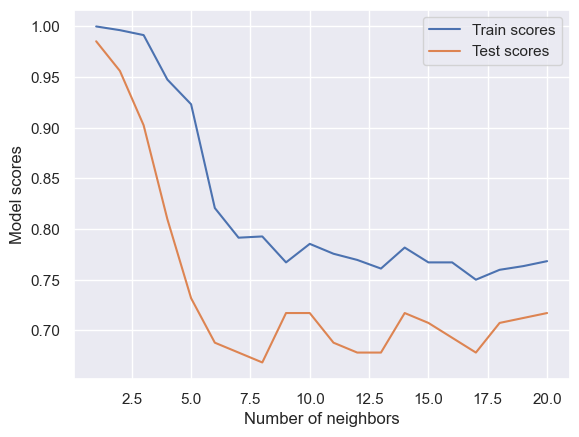

In [34]:
plt.plot(neighbors, train_scores, label="Train scores")
plt.plot(neighbors, test_scores, label="Test scores")
plt.xlabel("Number of neighbors")
plt.ylabel("Model scores")
plt.legend()

print(f"Maximum KNN score on the test data: {max(test_scores)*100:.2f}%")

### Hyperparameter tuning with the RandomizedSearchCV

RandomizedSearchCV() works by samples a fixed number of random combination from parameter space. This method doesn't try all combinations, so it's much faster but the model may miss the best parameter.

In Logistic Regression, the key hyperparameters list below
- Penalty (penalty): Specifies the type of regularization to apply. Options: 'l1', 'l2', 'elasticnet', or None. 'l1' (Lasso): Shrinks some coefficients to zero, useful for feature selection. 'l2' (Ridge): Shrinks coefficients but does not set them to zero. 'elasticnet': Combines L1 and L2 penalties, controlled by l1_ratio.

- Regularization Strength (C): Inverse of regularization strength (default: 1.0). Smaller values indicate stronger regularization, while larger values reduce regularization.

- Solver (solver): Determines the optimization algorithm. Options: 'lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga', 'newton-cholesky'. 'lbfgs': Default solver, suitable for small to medium datasets. 'liblinear': Best for small datasets and supports L1 regularization. 'sag' and 'saga': Faster for large datasets. 'newton-cg' and 'newton-cholesky': Effective for multiclass problems.

- Tolerance (tol): Stopping criteria for optimization (default: 1e-4). Smaller values lead to more precise solutions but may increase computation time.

- Maximum Iterations (max_iter): Maximum number of iterations for solvers to converge (default: 100). Increase this value if the solver fails to converge.

- Class Weights (class_weight): Adjusts weights inversely proportional to class frequencies. Options: None (default) or 'balanced'.

- Warm Start (warm_start): Reuses the solution from the previous fit to initialize the next fit. Useful for iterative model updates.

- Number of Jobs (n_jobs): Specifies the number of CPU cores to use for parallel computation. -1 uses all available cores.

In [35]:
# create a hyperpparameter grid for Logistic Regression
log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["liblinear"]}

# crate a hyperparameter grid for RandomForestClasifier
rf_grid = {"n_estimators": np.arange(10, 1000, 50),
           "max_depth": [None, 3, 5, 10],
           "min_samples_split": np.arange(2, 20, 2),
           "min_samples_leaf": np.arange(2, 20, 2)}

In [36]:
# Tune Logistic Regression
np.random.seed(42)

#setup random hyperparameter search for LogisticRegression
rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                            param_distributions = log_reg_grid,
                            cv = 5,
                            n_iter = 20,
                            verbose = True)

#fit random hyperparameter search model for LogisticRegression
rs_log_reg.fit(x_train, y_train)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fol

In [37]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': np.float64(1.623776739188721)}

In [38]:
rs_log_reg.score(x_test, y_test)

0.7853658536585366

Key Random Forest Hyperparameters
- n_estimators – Number of trees in the forest.
    Higher values → better performance but slower training.
- max_depth – Maximum depth of each tree.
    Controls overfitting; None means nodes expand until all leaves are pure.
- min_samples_split – Minimum samples required to split a node.
- min_samples_leaf – Minimum samples required at a leaf node.
- max_features – Number of features considered for the best split.
- bootstrap – Whether bootstrap samples are used when building trees.
- criterion – Function to measure split quality (gini or entropy for classification).

In [39]:
# fine tune RandomForestClassifier
## setup random seed
np.random.seed(42)

#setup random forest hyperparameter search for RandomFOrestClassifier
rs_rf = RandomizedSearchCV(RandomForestClassifier(),
                             param_distributions = rf_grid,
                             cv =5,
                             n_iter = 20,
                             verbose = True)

#fit random hyperparameter search model for RandomForestClassifier
rs_rf.fit(x_train, y_train)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 3, ...], 'min_samples_leaf': array([ 2, 4..., 14, 16, 18]), 'min_samples_split': array([ 2, 4..., 14, 16, 18]), 'n_estimators': array([ 10, ...60, 910, 960])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-valid

In [40]:
#find the best hyperparameters
rs_rf.best_params_

{'n_estimators': np.int64(510),
 'min_samples_split': np.int64(14),
 'min_samples_leaf': np.int64(2),
 'max_depth': None}

In [41]:
# eavaluate the randomized search RandomForestClassifier model
rs_rf.score(x_test, y_test)

0.926829268292683

### Hyperparameter tuning with GridSearchCv
Since RandomForestClassifier model provides the best score so far, we'll try and improve them again using GridSearchCV. 

Grid search is a powerful technique for hyper-parameter tuning in machine learning models. It involves exhaustively searching over a specified parameter grid to find the best combination of hyper-parameters for a given estimator.


In [ ]:
# create a hyperparameter grid for RandomForestClassifier
rf_grid = {"n_estimators": np.arange(10, 1000, 50),
           "max_depth": [None, 3, 5, 10],
           "min_samples_split": np.arange(2, 20, 2),
           "min_samples_leaf": np.arange(1, 30, 2)}

# setup random seed
np.random.seed(42)

# setup random forest hyperparameter search for RandomForestClassifier
gs_rf = GridSearchCV(RandomForestClassifier(),
                     param_grid = rf_grid,
                     cv = 5,
                     n_jobs = 20,
                     verbose = True)

# fit random hyperparameter search model for RandomForestClassifier
gs_rf.fit(x_train, y_train)


Fitting 5 folds for each of 10800 candidates, totalling 54000 fits


In [ ]:
gs_rf.best_params_

{'max_depth': None,
 'min_samples_leaf': np.int64(1),
 'min_samples_split': np.int64(2),
 'n_estimators': np.int64(360)}

In [ ]:
gs_rf.score(x_test, y_test)

0.9853658536585366

### Evaluating the tuned machine learning classifier

- Confussion matrix - Matrix that categorizes predictions into four outcomes: True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN).
- ROC curve and AUC score - The area under the ROC curve, which plots TPR against FPR across all thresholds. It provides a comprehensive measure of the model's performance in ranking positive cases higher than negative ones. A higher ROC-AUC indicates a better model performance.
- Precission - Measures the proportion of true positive prediction that were correctly identified as positive. It is calculated as TP / (TP+FP)
- Recall - Measures the proportion of true positive predictions that were correctly identified as positive. It is calculated as TP/ (TP+FN)
- F1-score - The harmonic mean of precision and recall, providing a single metric that balances both. The formula is: F1-Score = 2 * (Precision * Recall) / (Precision + Recall)

In [ ]:
# make predictions with tuned models
rs_preds = rs_rf.predict(x_test)
gs_preds = gs_rf.predict(x_test)

In [ ]:
y_test

527    1
359    1
447    0
31     1
621    0
      ..
832    1
796    1
644    1
404    0
842    0
Name: target, Length: 205, dtype: int64

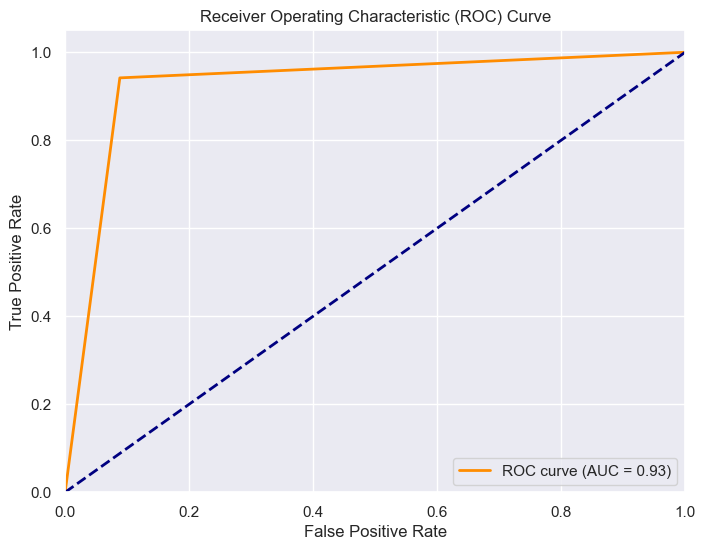

In [ ]:
# plot ROC curve and calculate AUC metric
fpr, tpr, thresholds = roc_curve(y_test, rs_preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

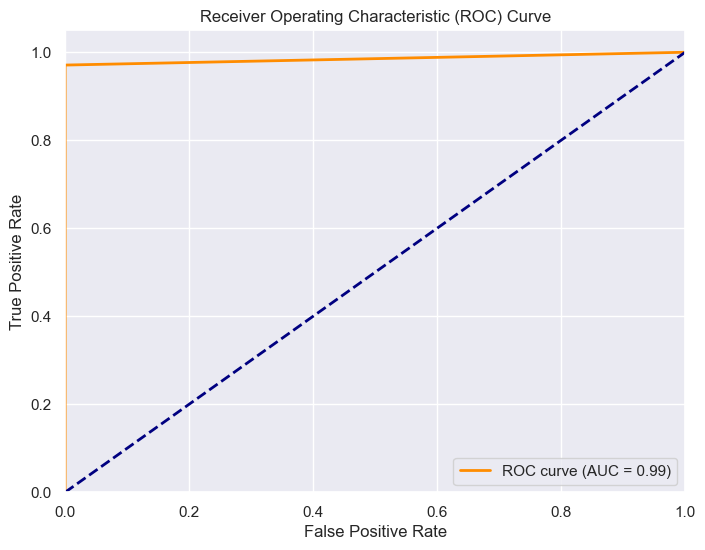

In [ ]:
# plot ROC curve and calculate AUC metric
fpr, tpr, thresholds = roc_curve(y_test, gs_preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# confussion matrix from rs_preds
print(confusion_matrix(y_test, rs_preds))

[[93  9]
 [ 6 97]]


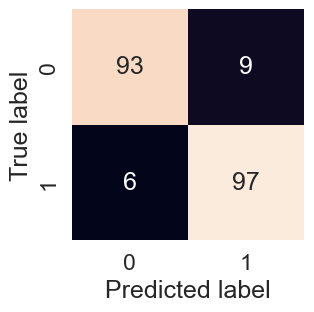

In [ ]:
sns.set(font_scale=1.5)

def plot_conf_mat(y_test, y_preds):
    """
    Plots a confusion matrix using seaborn's heatmap.
    """
    fig, ax = plt.subplots(figsize=(3,3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True,
                     cbar=False)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

plot_conf_mat(y_test, rs_preds)

In [ ]:
# confusion matrix from gs_preds
print(confusion_matrix(y_test, gs_preds))

[[102   0]
 [  3 100]]


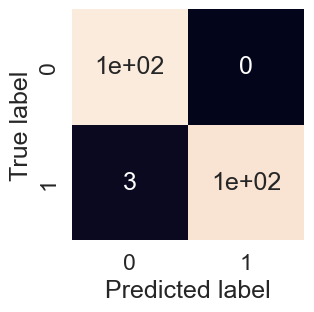

In [ ]:
plot_conf_mat(y_test, gs_preds)

## Classification report, cross-validation, and F1-Score

In [ ]:
print(classification_report(y_test, rs_preds))

              precision    recall  f1-score   support

           0       0.94      0.91      0.93       102
           1       0.92      0.94      0.93       103

    accuracy                           0.93       205
   macro avg       0.93      0.93      0.93       205
weighted avg       0.93      0.93      0.93       205



In [ ]:
print(classification_report(y_test, gs_preds))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



## Building prediction system for GridSearchCV and RandomSearchCV of RandomForestClassifier model

In [ ]:
patient = pd.DataFrame({
    "age":[52],
    "sex":[1],
    "cp":[0],
    "trestbps":[125],
    "chol":[212],
    "fbs":[0],
    "restecg":[1],
    "thalach":[168],
    "exang":[0],
    "oldpeak":[1.0],
    "slope":[2],
    "ca":[2],
    "thal":[3]
})

gs_rf.predict(patient)

NameError: name 'gs_rf' is not defined

In [ ]:
patient = pd.DataFrame({
    "age":[52],
    "sex":[1],
    "cp":[0],
    "trestbps":[125],
    "chol":[212],
    "fbs":[0],
    "restecg":[1],
    "thalach":[168],
    "exang":[0],
    "oldpeak":[1.0],
    "slope":[2],
    "ca":[2],
    "thal":[3]
})

rs_rf.predict()

C:\Users\Jihan\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([0])